# LaunchML Week 4 Mini Capstone
## House Price Prediction with Linear Regression

**Student name:** Abenezer Abebe

This notebook is a guided template. Read every Markdown instruction, complete the missing work, and explain your decisions in your own words. Do not submit a notebook that contains only code.

**Project question:** How accurately can a Linear Regression model predict house sale prices from the available property features?

> The dataset is synthetic and educational. It is not official property-market data.


## 1. Problem definition

Before writing code, explain:

- What is the target variable?
- Is this regression or classification? Why?
- What information might help predict the target?

Answer:The target variable is sale_price, a continuous dollar amount. This is a regression problem, not classification, because the goal is to predict a numeric value rather than assign a category. Information likely to help predict price includes house area, lot area, bedrooms, bathrooms, year built, overall quality rating, garage capacity, basement area, distance to the city center, neighborhood, and renovation status — all features that plausibly relate to how much a house is worth.

## 2. Import libraries and configure the notebook

Use NumPy, Pandas, Matplotlib, and the required scikit-learn tools. Set a readable plotting style.


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)


## 3. Load the dataset

Upload `launchml_house_prices.csv` to your Colab session if needed. If you are running this notebook from the supplied repository, use the path below.


In [33]:
DATA_PATH = "/content/launchml_house_prices.csv"
# In Google Colab, change DATA_PATH to the location of the uploaded CSV if necessary.
df = pd.read_csv(DATA_PATH)
df.head()


,house_area_sqft,lot_area_sqft,bedrooms,bathrooms,year_built,overall_quality,garage_capacity,basement_area_sqft,distance_to_city_center_km,neighborhood,renovation_status,sale_price
0,2276.0,6818.0,6.0,4.5,1972.0,7.0,2.0,1391.0,11.0,Yeka,Not renovated,1236544.0
1,1910.0,6308.0,5.0,4.0,1986.0,5.0,2.0,604.0,16.9,Nifas Silk,Partially renovated,824039.0
2,1900.0,4385.0,3.0,2.0,1993.0,7.0,2.0,0.0,6.0,Lideta,Not renovated,927803.0
3,1850.0,6478.0,3.0,2.0,2007.0,8.0,2.0,1518.0,5.7,Lideta,NaN,936696.0
4,1067.0,3637.0,2.0,2.0,1960.0,3.0,1.0,530.0,1.3,Arada,Fully renovated,559547.0


## 4. Inspect the dataset

Run the checks below. Then write a short interpretation after the code. Do not only report numbers; explain what the checks tell you about the data.


In [34]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe(include="all").T


Shape: (1100, 12)

Columns:
['house_area_sqft', 'lot_area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'overall_quality', 'garage_capacity', 'basement_area_sqft', 'distance_to_city_center_km', 'neighborhood', 'renovation_status', 'sale_price']

Data types:
house_area_sqft               float64
lot_area_sqft                 float64
bedrooms                      float64
bathrooms                     float64
year_built                    float64
overall_quality               float64
garage_capacity               float64
basement_area_sqft            float64
distance_to_city_center_km    float64
neighborhood                   object
renovation_status              object
sale_price                    float64
dtype: object

Missing values:
house_area_sqft                0
lot_area_sqft                 25
bedrooms                       0
bathrooms                     12
year_built                     0
overall_quality                0
garage_capacity               43
basement_area_sqft      

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
house_area_sqft,1100.0,NaN,NaN,NaN,1601.250909,565.893564,550.0,1203.25,1533.5,1891.75,4175.0
lot_area_sqft,1075.0,NaN,NaN,NaN,4688.053953,2187.862027,900.0,3120.5,4349.0,5860.5,15202.0
bedrooms,1100.0,NaN,NaN,NaN,3.643636,1.327358,1.0,3.0,4.0,5.0,6.0
bathrooms,1088.0,NaN,NaN,NaN,2.959099,1.035004,1.0,2.0,3.0,3.5,5.0
year_built,1100.0,NaN,NaN,NaN,1994.0,18.525982,1940.0,1982.0,1994.0,2008.0,2024.0
overall_quality,1100.0,NaN,NaN,NaN,6.176364,1.524977,1.0,5.0,6.0,7.0,10.0
garage_capacity,1057.0,NaN,NaN,NaN,1.593188,0.903,0.0,1.0,2.0,2.0,3.0
basement_area_sqft,1046.0,NaN,NaN,NaN,665.744742,533.816343,0.0,208.5,641.0,978.0,2600.0
distance_to_city_center_km,1077.0,NaN,NaN,NaN,5.51857,3.49338,0.5,2.9,4.8,7.3,18.0
neighborhood,1080,6,Bole,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Your inspection notes

Record the important observations from the previous output. Mention the target column, categorical columns, missing values, and duplicate rows.

Answer: The dataset has 1,100 rows and 12 columns: 9 numerical predictors, 2 categorical predictors (neighborhood, renovation_status), and the target column sale_price. Seven columns contain missing values — lot_area_sqft (25), bathrooms (12), garage_capacity (43), basement_area_sqft (54), distance_to_city_center_km (23), neighborhood (20), and renovation_status (26) — while sale_price itself has no missing values, which is expected since the target should always be present. There are no duplicate rows. sale_price ranges from about $240,622 to $2,430,174 with a mean of roughly $880,829, so the data covers a fairly wide range of property values.



## 5. Clean and prepare the data

The modeling pipeline below handles missing numerical values with the median, missing categorical values with the most frequent category, and categorical values with one-hot encoding. The preprocessing is fitted only on the training data through the pipeline, which helps prevent information from the test set leaking into training.

Before using it, identify the numerical and categorical predictor columns. Keep `sale_price` out of `X`.


In [35]:
target = "sale_price"
X = df.drop(columns=[target])
y = df[target]

numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])


Numerical features: ['house_area_sqft', 'lot_area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'overall_quality', 'garage_capacity', 'basement_area_sqft', 'distance_to_city_center_km']
Categorical features: ['neighborhood', 'renovation_status']


## 6. Exploratory analysis

Use tables and charts to investigate the data before modeling. The first required visualization is a scatter plot of house area and sale price. Add a fitted line using `np.polyfit`.

Write an interpretation below the chart. A relationship does not prove causation.


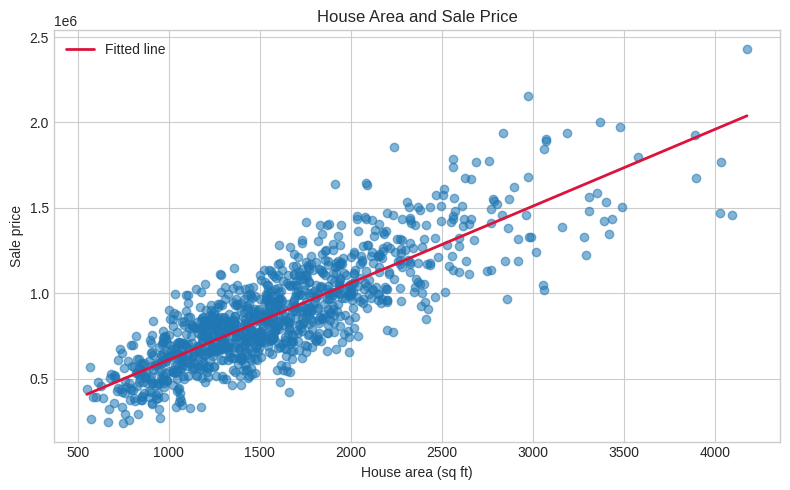

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(df["house_area_sqft"], df["sale_price"], alpha=0.55)
valid = df[["house_area_sqft", "sale_price"]].dropna()
line_x = np.linspace(valid["house_area_sqft"].min(), valid["house_area_sqft"].max(), 100)
line_y = np.polyval(np.polyfit(valid["house_area_sqft"], valid["sale_price"], 1), line_x)
plt.plot(line_x, line_y, color="crimson", linewidth=2, label="Fitted line")
plt.title("House Area and Sale Price")
plt.xlabel("House area (sq ft)")
plt.ylabel("Sale price")
plt.legend()
plt.tight_layout()
plt.savefig("visualization_1_house_area_vs_price.png", dpi=150)
plt.show()


### Interpretation of visualization 1

What pattern do you observe? Mention the direction, strength, and any unusual points you notice.

Answer: There is a clear, strong positive relationship between house area and sale price: as house area increases, sale price consistently increases too. The fitted line tracks the overall trend closely for most of the data, though the scatter widens somewhat at larger house sizes, and a few high-priced outliers appear above about 3,500 sqft. This pattern suggests house area is one of the stronger predictors of price, though it doesn't prove area alone causes the price — other related factors, like quality or neighborhood, could also contribute.

## 7. Split the data and train Linear Regression

Use a reproducible 80/20 train-test split. The model must be Linear Regression only.


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 880
Testing rows: 220


## 8. Evaluate the model

Calculate the required metrics. Then explain what each value means in the context of price prediction.


In [38]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae, mse, rmse, r2]
})
metrics


,Metric,Value
0,MAE,8.305102e+04
1,MSE,1.191163e+10
2,RMSE,1.091404e+05
3,R2,8.811078e-01


### Metric interpretation

- **MAE:** Explain the average absolute prediction error in price units.
- **MSE:** Explain what squaring errors does to the metric.
- **RMSE:** Explain why it is often easier to interpret than MSE.
- **R²:** Explain what the value suggests about variation explained on the test set.

Answer: MAE is $83,051, meaning the model's predictions are off by about $83,000 on average, in either direction. MSE is 1.19 × 10¹⁰ — squaring the errors before averaging means larger mistakes are penalized more heavily than smaller ones, but the result is in squared dollars, which isn't easy to interpret directly. RMSE is $109,140, the square root of MSE, which brings the value back into normal dollar units and is a bit higher than MAE because it's more sensitive to the model's largest errors. R² is 0.881, meaning the model explains about 88.1% of the variation in sale price on the test set — a strong fit, though roughly 12% of the variation remains unexplained by these features and this linear model.

## 9. Review predictions

Create a table with actual prices, predicted prices, and errors. Then discuss whether the largest errors appear concentrated in particular price ranges.


In [39]:
prediction_review = pd.DataFrame({
    "actual_sale_price": y_test.to_numpy(),
    "predicted_sale_price": y_pred
})
prediction_review["error"] = prediction_review["actual_sale_price"] - prediction_review["predicted_sale_price"]
prediction_review["absolute_error"] = prediction_review["error"].abs()
prediction_review.sort_values("absolute_error", ascending=False).head(10)


,actual_sale_price,predicted_sale_price,error,absolute_error
61,1639114.0,1.154762e+06,484351.705580,484351.705580
113,1857541.0,1.456766e+06,400775.003017,400775.003017
146,1459473.0,1.818509e+06,-359036.389406,359036.389406
118,908277.0,1.182597e+06,-274319.891203,274319.891203
219,796030.0,5.240059e+05,272024.051179,272024.051179
18,766620.0,1.009193e+06,-242572.728762,242572.728762
63,483197.0,7.216338e+05,-238436.758149,238436.758149
110,817040.0,5.847659e+05,232274.119494,232274.119494
198,682899.0,8.984281e+05,-215529.116765,215529.116765
128,1611705.0,1.403665e+06,208040.387366,208040.387366


## 10. Required visualization 2: actual versus predicted prices

Points close to the reference line represent predictions close to actual values.


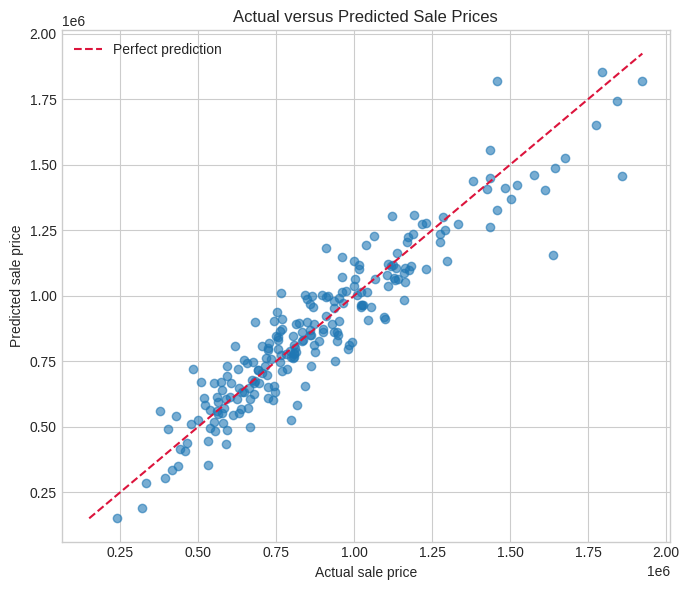

In [40]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], color="crimson", linestyle="--", label="Perfect prediction")
plt.title("Actual versus Predicted Sale Prices")
plt.xlabel("Actual sale price")
plt.ylabel("Predicted sale price")
plt.legend()
plt.tight_layout()
plt.savefig("visualization_2_actual_vs_predicted.png", dpi=150)
plt.show()


### Interpretation of visualization 2

Explain how closely the points follow the reference line and what that suggests about prediction accuracy.

Answer: Most points sit close to the "perfect prediction" reference line, particularly in the roughly $250,000–$1,250,000 range, showing good agreement between actual and predicted prices for most of the test set. A smaller number of points, mostly higher-priced homes, fall noticeably off the line — some above it, some below — meaning the model's predictions become less reliable at the top end of the price range.


## 11. Required visualization 3: prediction errors

A residual is actual value minus predicted value. A random-looking pattern around zero is generally easier to interpret than a clear curve or funnel shape.


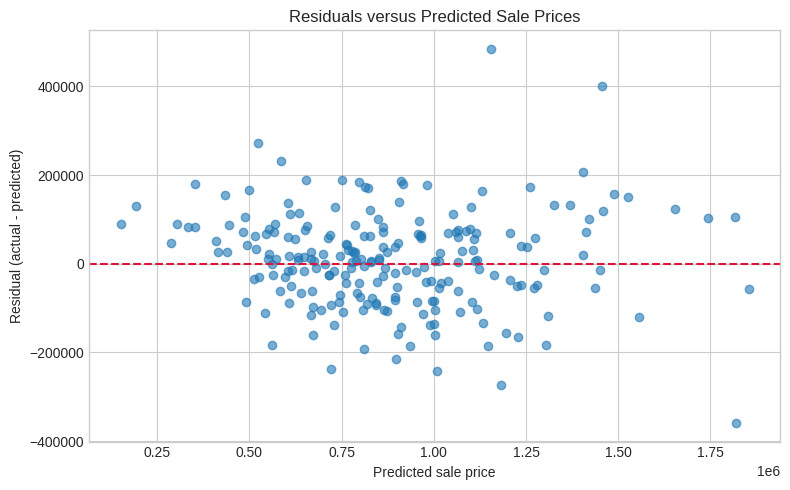

In [41]:
residuals = y_test.to_numpy() - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="crimson", linestyle="--")
plt.title("Residuals versus Predicted Sale Prices")
plt.xlabel("Predicted sale price")
plt.ylabel("Residual (actual - predicted)")
plt.tight_layout()
plt.savefig("visualization_3_residuals.png", dpi=150)
plt.show()


### Interpretation of visualization 3

Describe whether the residuals are centered around zero, whether their spread changes, and whether you see unusual points or patterns.

Answer : The residuals are centered around zero across most of the predicted-price range, which suggests the model isn't systematically over- or under-predicting overall. However, the spread of residuals widens at higher predicted prices, and the largest individual errors (several between $200,000 and $480,000) occur among the more expensive homes. This funnel-like widening suggests the linear model is less consistent for higher-priced properties than for mid-range ones.


## 12. Interpretation and limitations

Write a complete interpretation using your own metric values and visual evidence. Address:

1. Which features appeared most related to price?
2. What did you do with missing values and why?
3. How well did the model perform?
4. Where did it make larger errors?
5. What are at least three limitations?

Remember that the data are synthetic and that association does not prove causation.

Answer : house_area_sqft showed the clearest relationship with sale_price during exploration. Missing values were handled by filling numerical columns with their median (to avoid outliers skewing the fill) and categorical columns with their most frequent category, using a scikit-learn pipeline fitted only on the training data to avoid leaking test-set information into training. The model performed well overall, with an R² of 0.881 and an average error of about $83,000, but it made larger errors on higher-priced homes, likely because Linear Regression can only capture straight-line relationships and the housing market at the top end may not behave linearly. Limitations: (1) the dataset is synthetic and educational, not real market data; (2) Linear Regression can't capture non-linear pricing patterns; (3) imputed missing values are a simplification that may understate true variability; (4) a relationship between a feature and price doesn't prove causation; (5) with 1,100 rows and 11 predictors, the sample size is fairly modest.


## 13. Final conclusion

Answer the project question directly in one or two paragraphs. State what you learned about data preparation, Linear Regression, evaluation, and communicating results.

Answer : This project shows that a Linear Regression model can predict house sale prices in this dataset reasonably well, explaining about 88% of the variance in price on unseen test data with a typical error of roughly $83,000. House area was the most visibly influential feature explored. The model was most accurate for mid-range-priced homes and less precise for higher-priced ones, reflecting the limits of a linear model on a synthetic dataset. Working through this project reinforced why train-test splitting matters, why missing values need a deliberate, explainable strategy before modeling, and why evaluation metrics and residual plots should be interpreted together rather than relying on a single number.


## 14. Submission reminder

Before submission:

- Run all cells from top to bottom.
- Confirm there are no errors.
- Move the three PNG files into your repository `images/` folder.
- Complete the written report.
- Upload the notebook, report, dataset, and images to GitHub.
- Check that your README explains how to run the project.
